In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Load the dataset
df = pd.read_csv(
    '../model/data/raw/reviews.tsv.txt',
    sep='\t',
    header=None,
    names=['rating', 'review_id', 'user_id', 'book_id', 'review_text']
)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (63257, 5)


,rating,review_id,user_id,book_id,review_text
0,4,338670838,7878381,13431841,"""عزازيل الذي صنعناه ،الكامن في أنفسنا"" يذكرني..."
1,4,39428407,1775679,3554772,من أمتع ما قرأت من روايات بلا شك. وحول الشك ت...
2,4,32159373,1304410,3554772,رواية تتخذ من التاريخ ،جوًا لها اختار المؤلف ...
3,1,442326656,11333112,3554772,إني أقدّر هذه الرواية كثيرا، لسبب مختلف عن أس...
4,5,46492258,580165,3554772,الكاهن الذي أطلق على نفسه اسم هيبا تيمنا بالع...


In [2]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63257 entries, 0 to 63256
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   rating       63257 non-null  int64 
 1   review_id    63257 non-null  int64 
 2   user_id      63257 non-null  int64 
 3   book_id      63257 non-null  int64 
 4   review_text  63257 non-null  object
dtypes: int64(4), object(1)
memory usage: 2.4+ MB


In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing review texts: {df['review_text'].isnull().sum()}")
print(f"Total missing ratings: {df['rating'].isnull().sum()}")

Missing values per column:
rating         0
review_id      0
user_id        0
book_id        0
review_text    0
dtype: int64

Total missing review texts: 0
Total missing ratings: 0


Rating value counts:
rating
1     2939
2     5285
3    12201
4    19054
5    23778
Name: count, dtype: int64


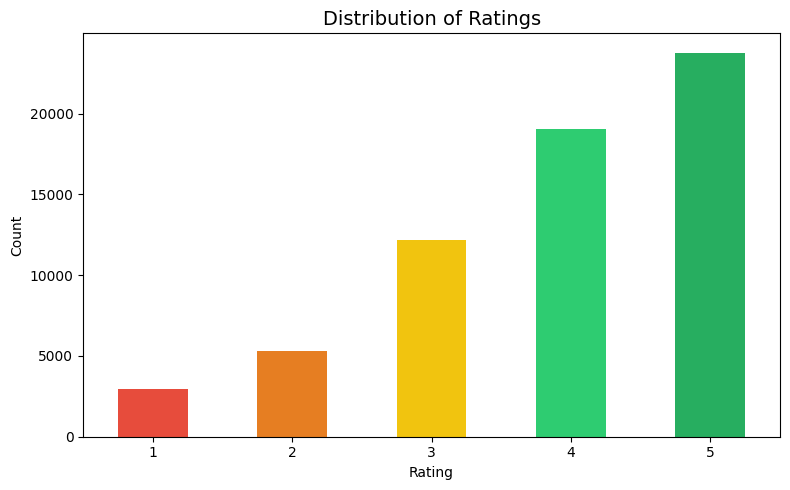

In [4]:
# Rating distribution
print("Rating value counts:")
print(df['rating'].value_counts().sort_index())

plt.figure(figsize=(8, 5))
df['rating'].value_counts().sort_index().plot(kind='bar', color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60'])
plt.title('Distribution of Ratings', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
# Check unique values
print(f"Unique ratings: {sorted(df['rating'].unique())}")
print(f"Unique users: {df['user_id'].nunique()}")
print(f"Unique books: {df['book_id'].nunique()}")

Unique ratings: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Unique users: 16486
Unique books: 2131


In [6]:
# Text length analysis
df['text_length'] = df['review_text'].astype(str).apply(len)
df['word_count'] = df['review_text'].astype(str).apply(lambda x: len(x.split()))

print("Text Length (characters):")
print(df['text_length'].describe())
print(f"\nWord Count:")
print(df['word_count'].describe())

Text Length (characters):
count    63257.000000
mean       334.131274
std        587.479047
min          2.000000
25%         73.000000
50%        168.000000
75%        360.000000
max      19088.000000
Name: text_length, dtype: float64

Word Count:
count    63257.000000
mean        62.002988
std        108.074446
min          1.000000
25%         14.000000
50%         31.000000
75%         67.000000
max       3419.000000
Name: word_count, dtype: float64


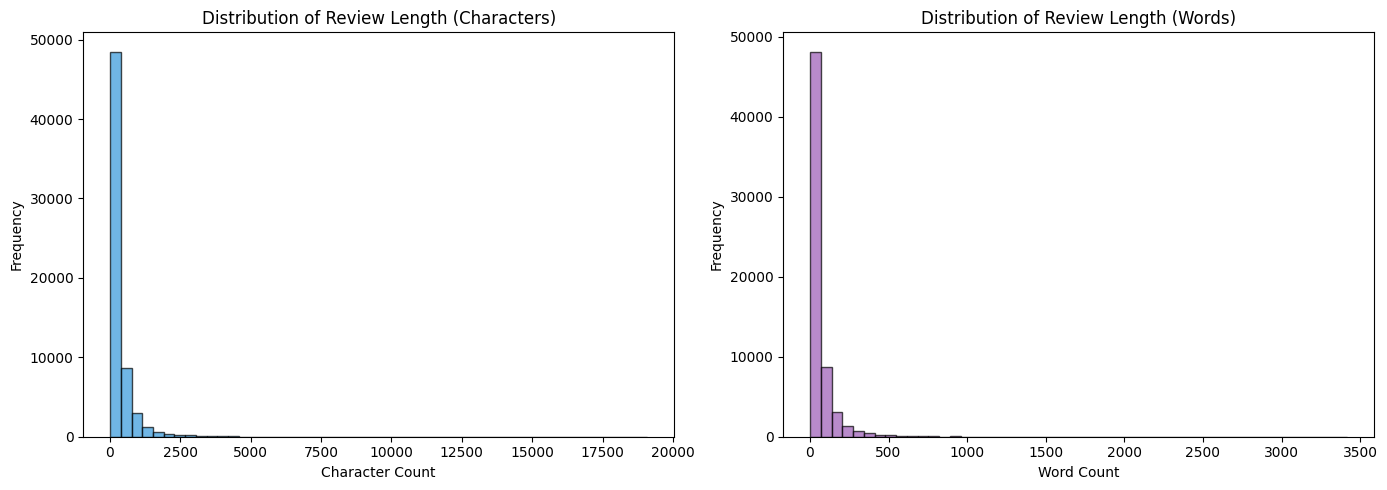

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length distribution
axes[0].hist(df['text_length'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Review Length (Characters)')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

# Word count distribution
axes[1].hist(df['word_count'], bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Review Length (Words)')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Average word count per rating:
rating
1    54.2
2    61.8
3    65.0
4    65.1
5    59.1
Name: word_count, dtype: float64


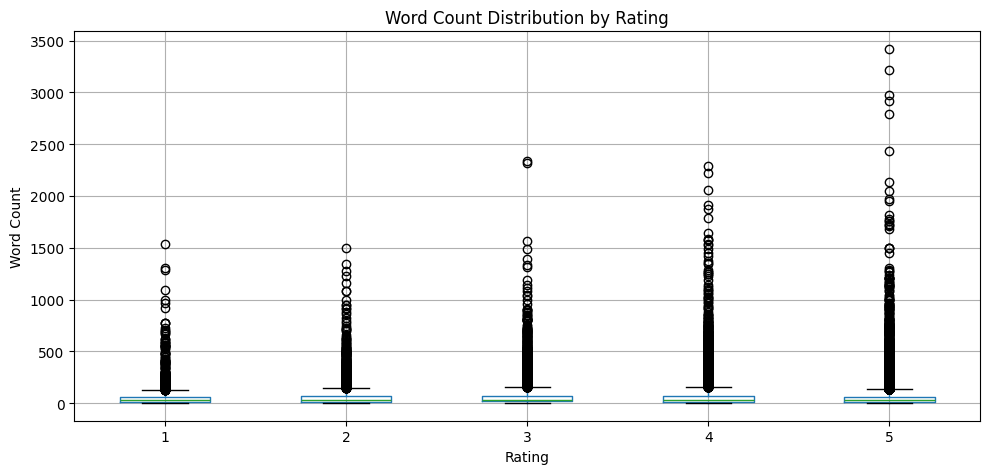

In [8]:
# Average text length per rating
print("Average word count per rating:")
print(df.groupby('rating')['word_count'].mean().round(1))

df.boxplot(column='word_count', by='rating', figsize=(10, 5))
plt.title('Word Count Distribution by Rating')
plt.suptitle('')
plt.xlabel('Rating')
plt.ylabel('Word Count')
plt.tight_layout()
plt.show()

In [9]:
# Check for duplicate reviews
print(f"Total rows: {len(df)}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate review texts: {df['review_text'].duplicated().sum()}")

Total rows: 63257
Duplicate rows: 2459
Duplicate review texts: 3167


In [10]:
# Sample reviews from each rating
for rating in sorted(df['rating'].dropna().unique()):
    print(f"\n{'='*80}")
    print(f"⭐ Rating: {rating}")
    print(f"{'='*80}")
    sample = df[df['rating'] == rating]['review_text'].dropna().iloc[0]
    print(sample[:300], "..." if len(str(sample)) > 300 else "")


⭐ Rating: 1
 إني أقدّر هذه الرواية كثيرا، لسبب مختلف عن أسباب الآخرين، ألا وهو أنها علمتني درسا قيما، حتى وإن كانت العبرة قد أتت بعد فوات الأوان، وذلك عهدنا بدروس الحياة. علمتني الرواية أن الصديق الذي يشجعك على قراءة مثيلاتها دون أي إشارة إلى المقاطع الإباحية التي هي فيها، هو حتما صديق غير جدير بالثقة ! قد تقول ...

⭐ Rating: 2
 انا كان عندى شغف قوى جدا لاقرأه وبعد ان تعمقت فيه وجدته اقل من توقعاتى :(( استوقفتنى فيه جملة اظنها رائعة : "اكتب يا هيبا فمن يكتب لا يموت ابدا" 

⭐ Rating: 3
 لم استوعب بداية أنها رواية حتى وصلت إلى المنتصف تقريبا وقرأت في مكان ما أنها غير واقعية . كانت هذه صدمة. فطريقة كتابة الرواية وحيث أنها أولا: رقوع تعود للقرن الرابع الميلادي تحكي حياة الراهب هيبا ترجمها المترجم "حقيقة هو المؤلف" من اللغة الارآمية إلى العربية. ثانيا: إخباره بالمقدمة عن وجود هوامش عر ...

⭐ Rating: 4
 "عزازيل الذي صنعناه ،الكامن في أنفسنا" يذكرني يوسف زيدان بــ بورخس في استخدامه لحيلته الفنية،وخداع القاريء بأن الرواية ترجمة لمخطوط قديم. الهوامش المخترعة و اختلاق وجود مترجـِم عاد بي إلى بو

In [11]:
# Check for empty or very short reviews
empty_reviews = df[df['review_text'].astype(str).str.strip().isin(['', 'nan'])].shape[0]
short_reviews = df[df['word_count'] < 3].shape[0]

print(f"Empty reviews: {empty_reviews}")
print(f"Very short reviews (< 3 words): {short_reviews}")
print(f"\nSample short reviews:")
print(df[df['word_count'] < 3]['review_text'].head(10).tolist())

Empty reviews: 0
Very short reviews (< 3 words): 1548

Sample short reviews:
[' تحفه', ' حقيقىروايةخايبةجدامبالغةوتطويلزيادةاسقاطاحداثخياليةعلى امورتراثيىةوخلطياخذكحتىلاتعرفماالحقيقىوماالخيالى', ' رواية مثرية', ' رواية رائعة', ' فوق الفظيع', ' روايه رائعه', ' كتاب رائع', ' جيد جدا', ' أبهرتنى', ' تحفه']
